РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

1. ЗАГРУЗКА И ОБЪЕДИНЕНИЕ ДАННЫХ
car_data.csv: 278 строк, 10 столбцов
CAR_DETAILS_FROM_CAR_DEKHO.csv: 3369 строк, 9 столбцов
Car_details_v3.csv: 6497 строк, 14 столбцов

Объединённый датасет: 10144 строк, 16 столбцов
<class 'pandas.DataFrame'>
RangeIndex: 10144 entries, 0 to 10143
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           10144 non-null  str    
 1   year           10144 non-null  int64  
 2   price          10144 non-null  float64
 3   present_price  278 non-null    float64
 4   km_driven      10144 non-null  int64  
 5   fuel           10144 non-null  str    
 6   seller_type    10144 non-null  str    
 7   transmission   10144 non-null  str    
 8   owner          10144 non-null  object 
 9   source         10144 non-null  str    
 10  car_age        10144 non-null  int64  
 11  mileage        6306 non-null   str    
 12  engine         6306 non-null   

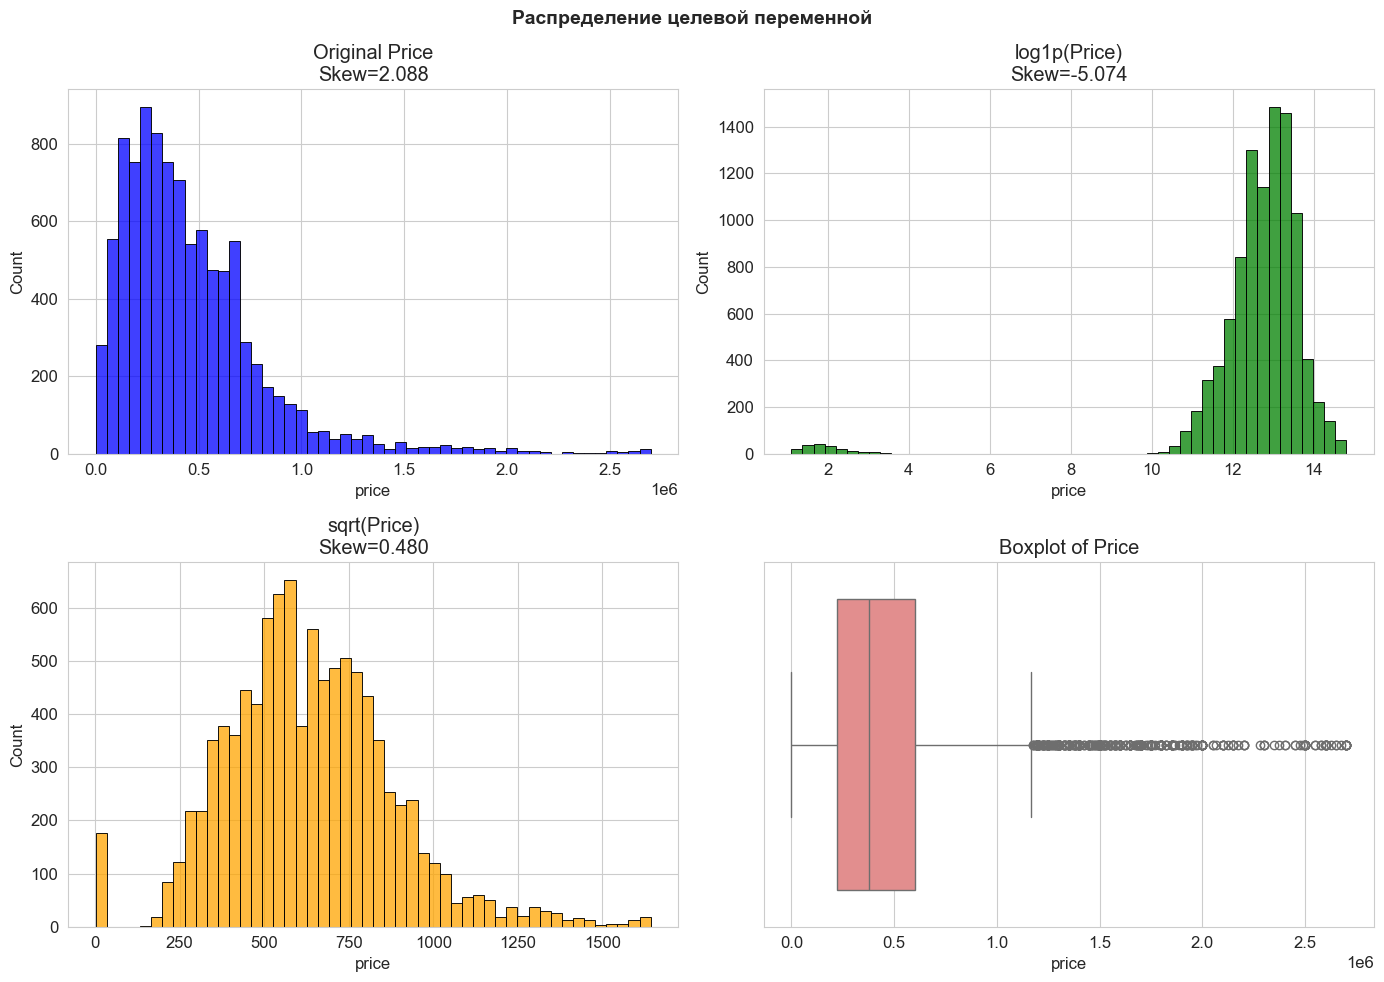

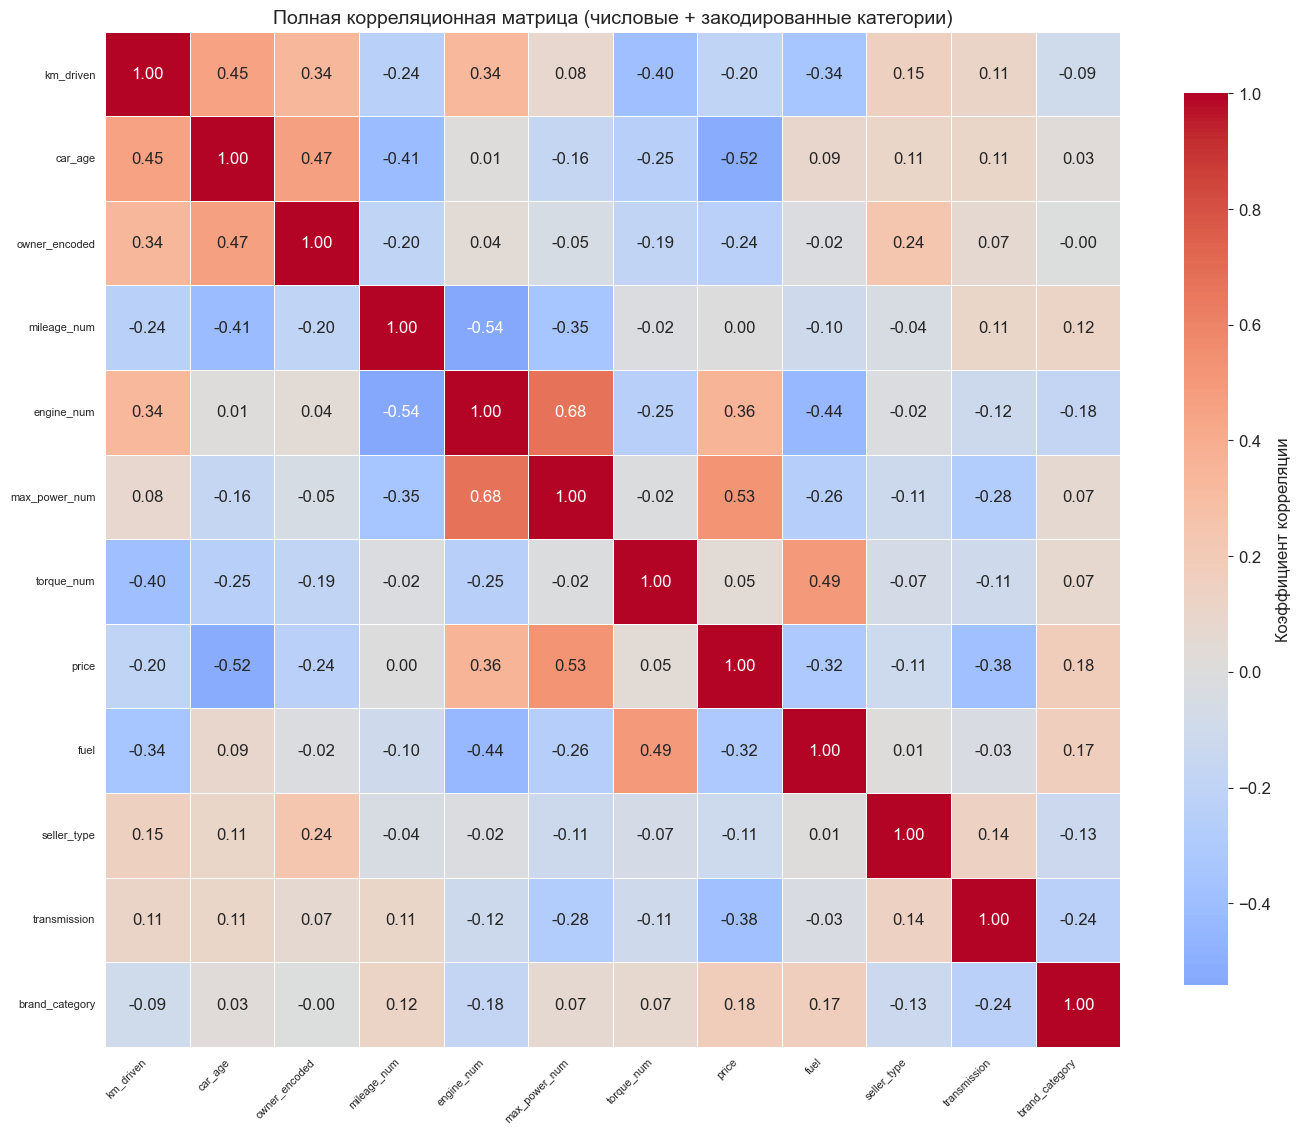

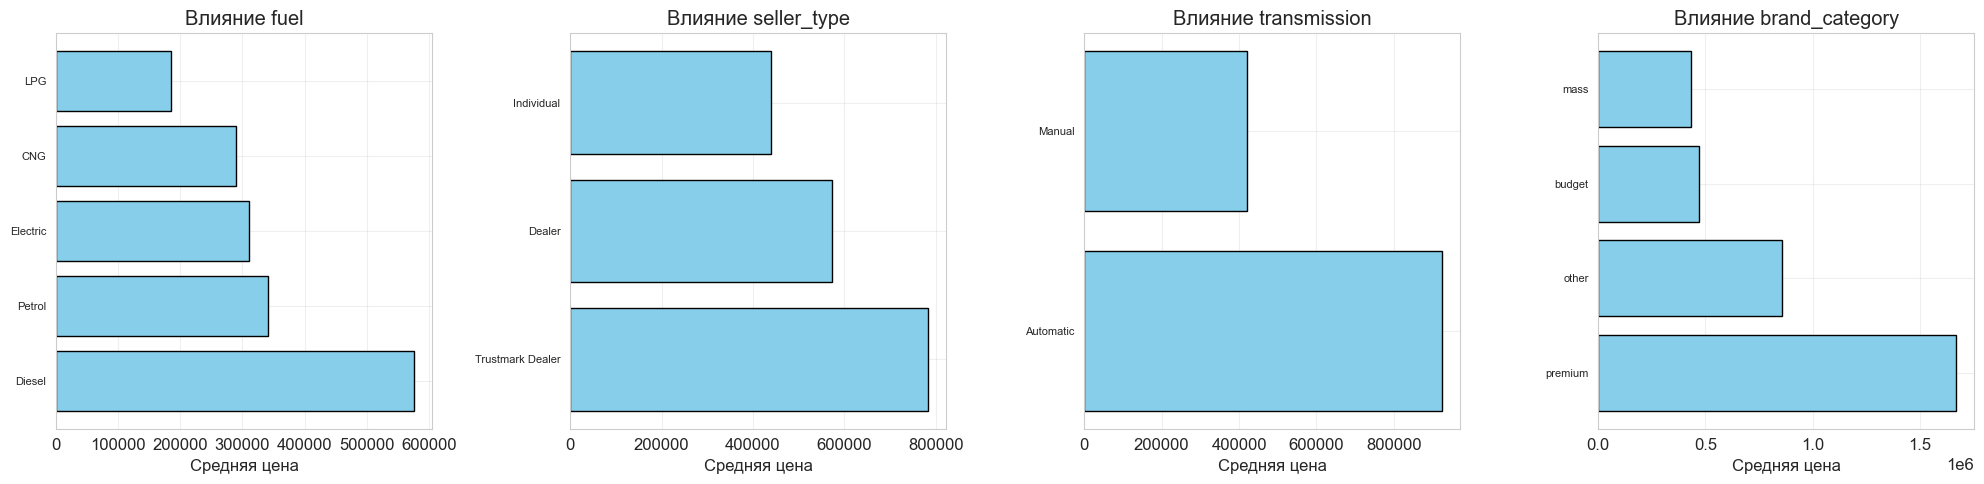

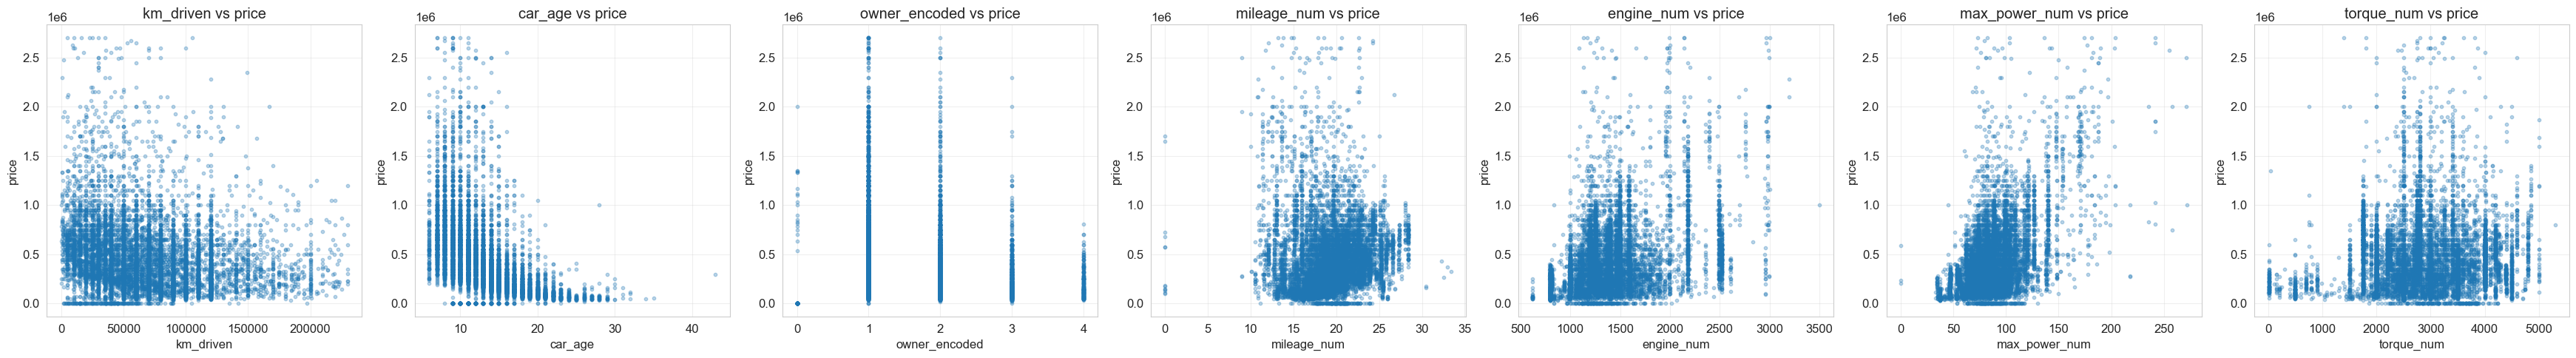

In [ ]:
"""
Разведочный анализ данных (EDA)

Запуск: python 01_eda_analysis.py
"""

import os
import sys
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, pearsonr, f_oneway
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import KNNImputer

warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

os.makedirs('reports/figures', exist_ok=True)

print("=" * 80)
print("РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)")
print("=" * 80)


def extract_number(value):
    """Извлечение числа из строки"""
    if pd.isna(value):
        return np.nan
    match = re.search(r'(\d+(?:\.\d+)?)', str(value))
    return float(match.group(1)) if match else np.nan


def extract_max_torque(value):
    """Извлечение максимального числа из диапазона torque"""
    if pd.isna(value):
        return np.nan
    numbers = re.findall(r'(\d+(?:\.\d+)?)', str(value))
    if not numbers:
        return np.nan
    return max(float(n) for n in numbers)


def extract_brand_from_name(name):
    """Извлечение бренда из полного названия"""
    if pd.isna(name):
        return 'unknown'
    name_clean = str(name).strip().lower()
    
    two_word_brands = ['land rover', 'range rover', 'mercedes benz', 'royal enfield']
    for brand in two_word_brands:
        if name_clean.startswith(brand):
            return brand.replace(' ', '_')
    
    first_word = name_clean.split()[0]
    return re.sub(r'[^\w\-]', '', first_word)


def extract_brand_from_model(model_name):
    """Определение бренда по названию модели (для car_data.csv)"""
    if pd.isna(model_name):
        return 'unknown'
    model_name = str(model_name).lower().strip()
    
    model_to_brand = {
        'swift': 'maruti', 'dzire': 'maruti', 'alto': 'maruti', 'wagon r': 'maruti',
        'ciaz': 'maruti', 'ritz': 'maruti', 'ertiga': 'maruti', 'baleno': 'maruti',
        'vitara brezza': 'maruti', 's-cross': 'maruti', 'ignis': 'maruti', 'celerio': 'maruti',
        'i20': 'hyundai', 'i10': 'hyundai', 'grand i10': 'hyundai', 'creta': 'hyundai',
        'verna': 'hyundai', 'xcent': 'hyundai', 'eon': 'hyundai', 'elantra': 'hyundai',
        'city': 'honda', 'amaze': 'honda', 'brio': 'honda', 'jazz': 'honda', 'wrv': 'honda',
        'fortuner': 'toyota', 'innova': 'toyota', 'corolla altis': 'toyota', 'etios': 'toyota',
        'figo': 'ford', 'ecosport': 'ford', 'endeavour': 'ford', 'fiesta': 'ford',
        'scorpio': 'mahindra', 'xuv500': 'mahindra', 'bolero': 'mahindra', 'thar': 'mahindra',
        'indica': 'tata', 'indigo': 'tata', 'nano': 'tata', 'tiago': 'tata', 'nexon': 'tata',
        'kwid': 'renault', 'duster': 'renault', 'lodgy': 'renault',
        'micra': 'nissan', 'sunny': 'nissan', 'terrano': 'nissan',
        'polo': 'volkswagen', 'vento': 'volkswagen'
    }
    
    if model_name in model_to_brand:
        return model_to_brand[model_name]
    
    for model, brand in model_to_brand.items():
        if model in model_name or model_name in model:
            return brand
    
    return 'unknown'


def categorize_brand(brand):
    """Смысловое группирование брендов"""
    if pd.isna(brand) or brand == 'unknown':
        return 'other'
    
    brand = str(brand).lower()
    
    premium = ['bmw', 'mercedes', 'audi', 'lexus', 'jaguar', 'land_rover', 'range_rover', 
               'volvo', 'porsche', 'ferrari', 'lamborghini', 'bentley', 'maserati', 'tesla']
    mass = ['maruti', 'hyundai', 'honda', 'toyota', 'ford', 'nissan', 'kia', 'volkswagen',
            'chevrolet', 'renault', 'skoda', 'mitsubishi', 'mazda', 'subaru', 'suzuki']
    budget = ['datsun', 'tata', 'mahindra', 'lada', 'chery', 'great_wall']
    sports = ['royal_enfield', 'ktm', 'yamaha', 'kawasaki', 'ducati', 'bajaj', 'hero']
    
    if brand in premium:
        return 'premium'
    elif brand in mass:
        return 'mass'
    elif brand in budget:
        return 'budget'
    elif brand in sports:
        return 'sports'
    return 'other'


print("\n" + "=" * 80)
print("1. ЗАГРУЗКА И ОБЪЕДИНЕНИЕ ДАННЫХ")
print("=" * 80)


def load_and_merge_data():
    """Загрузка и объединение трёх файлов"""
    
    df1 = pd.read_csv('C:/Users/Lenovo Legion/Desktop/ML/car_price_prediction/data/raw/car_data.csv')
    df1 = df1.drop_duplicates().reset_index(drop=True)
    df1.columns = df1.columns.str.lower()
    df1 = df1.rename(columns={
        'car_name': 'name', 'selling_price': 'price', 'present_price': 'present_price',
        'kms_driven': 'km_driven', 'fuel_type': 'fuel', 'seller_type': 'seller_type',
        'transmission': 'transmission', 'owner': 'owner'
    })
    df1['source'] = 'car_data'
    print(f"car_data.csv: {len(df1)} строк, {len(df1.columns)} столбцов")
    
    df2 = pd.read_csv('C:/Users/Lenovo Legion/Desktop/ML/car_price_prediction/data/raw/CAR_DETAILS_FROM_CAR_DEKHO.csv')
    df2 = df2.drop_duplicates().reset_index(drop=True)
    df2.columns = df2.columns.str.lower()
    df2 = df2.rename(columns={'selling_price': 'price', 'km_driven': 'km_driven'})
    df2['source'] = 'car_dekho'
    print(f"CAR_DETAILS_FROM_CAR_DEKHO.csv: {len(df2)} строк, {len(df2.columns)} столбцов")
    
    df3 = pd.read_csv('C:/Users/Lenovo Legion/Desktop/ML/car_price_prediction/data/raw/Car_details_v3.csv')
    df3 = df3.drop_duplicates().reset_index(drop=True)
    df3.columns = df3.columns.str.lower()
    df3 = df3.rename(columns={'selling_price': 'price', 'km_driven': 'km_driven'})
    df3['source'] = 'car_details_v3'
    print(f"Car_details_v3.csv: {len(df3)} строк, {len(df3.columns)} столбцов")
    
    current_year = 2026
    for df in [df1, df2, df3]:
        if 'year' in df.columns:
            df['car_age'] = current_year - df['year']
    
    df = pd.concat([df1, df2, df3], ignore_index=True)
    print(f"\nОбъединённый датасет: {len(df)} строк, {len(df.columns)} столбцов")
    
    return df, df1, df2, df3


df, df1, df2, df3 = load_and_merge_data()

df.info()

df.head()

df.describe()

print("\n" + "=" * 80)
print("2. ПРЕДОБРАБОТКА ДАННЫХ")
print("=" * 80)


def preprocess_data(df):
    """Предобработка данных: удаление выбросов, пропусков, создание признаков"""
    
    original_len = len(df)
    
    q_low = df['price'].quantile(0.01)
    q_high = df['price'].quantile(0.99)
    df = df[(df['price'] >= q_low) & (df['price'] <= q_high)]
    print(f"После удаления выбросов по цене: {len(df)} строк (удалено {original_len - len(df)})")
    
    q_km = df['km_driven'].quantile(0.99)
    df = df[df['km_driven'] <= q_km]
    print(f"После удаления выбросов по пробегу: {len(df)} строк (удалено {original_len - len(df)})")
    
    if 'mileage' in df.columns:
        df['mileage_num'] = df['mileage'].apply(extract_number)
    if 'engine' in df.columns:
        df['engine_num'] = df['engine'].apply(extract_number)
    if 'max_power' in df.columns:
        df['max_power_num'] = df['max_power'].apply(extract_number)
    if 'torque' in df.columns:
        df['torque_num'] = df['torque'].apply(extract_max_torque)
    
    df['owner'] = df['owner'].astype(str)
    owner_mapping = {
        '0': 0, '1': 1, '2': 2, '3': 3, '4': 4,
        'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3,
        'Fourth & Above Owner': 4, 'Test Drive Car': 0
    }
    df['owner_encoded'] = df['owner'].map(owner_mapping).fillna(0).astype(int)
    
    return df


df = preprocess_data(df)
print(f"\nПосле предобработки: {len(df)} строк, {len(df.columns)} столбцов")


print("\n" + "=" * 80)
print("3. ИЗВЛЕЧЕНИЕ И КАТЕГОРИЗАЦИЯ БРЕНДОВ")
print("=" * 80)


def process_brands(df):
    """Извлечение и категоризация брендов"""
    
    df['brand'] = None
    
    mask_car_data = df['source'] == 'car_data'
    if mask_car_data.any():
        df.loc[mask_car_data, 'brand'] = df.loc[mask_car_data, 'name'].apply(extract_brand_from_model)
    
    mask_other = ~mask_car_data & df['name'].notna()
    if mask_other.any():
        df.loc[mask_other, 'brand'] = df.loc[mask_other, 'name'].apply(extract_brand_from_name)
    
    df['brand'] = df['brand'].fillna('unknown')
    df['brand_category'] = df['brand'].apply(categorize_brand)
    
    drop_cols = ['name', 'year', 'owner', 'mileage', 'engine', 'max_power', 'torque', 
                 'present_price', 'source']
    for col in drop_cols:
        if col in df.columns:
            df = df.drop(col, axis=1)
    
    print(f"Категории брендов:\n{df['brand_category'].value_counts()}")
    
    return df


df = process_brands(df)
print(f"\nПосле обработки брендов: {len(df)} строк, {len(df.columns)} столбцов")


print("\n" + "=" * 80)
print("4. ЗАПОЛНЕНИЕ ПРОПУСКОВ")
print("=" * 80)


def fill_missing_values(df):
    """Заполнение пропусков: KNN для чисел, 'missing' для категорий"""
    
    numeric_cols = ['km_driven', 'car_age', 'owner_encoded', 'mileage_num', 
                    'engine_num', 'max_power_num', 'torque_num']
    numeric_cols = [c for c in numeric_cols if c in df.columns]
    
    if len(numeric_cols) > 1 and df[numeric_cols].dropna().shape[0] > 0:
        knn_imputer = KNNImputer(n_neighbors=5)
        df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])
        print("Числовые пропуски заполнены методом KNN")
    else:
        for col in numeric_cols:
            df[col] = df[col].fillna(df[col].median())
        print("Числовые пропуски заполнены медианой")
    
    cat_cols = ['fuel', 'seller_type', 'transmission', 'brand_category']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).fillna('missing')
    print("Категориальные пропуски заполнены значением 'missing'")
    
    return df, numeric_cols, cat_cols


df, numeric_cols, cat_cols = fill_missing_values(df)
print(f"\nПосле заполнения пропусков: {len(df)} строк, {len(df.columns)} столбцов")
print(f"Числовые колонки: {numeric_cols}")
print(f"Категориальные колонки: {cat_cols}")


print("\n" + "=" * 80)
print("5. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (PRICE)")
print("=" * 80)

y = df['price']
y_log = np.log1p(y)
y_sqrt = np.sqrt(y)

print(f"Статистика исходной цены:")
print(f"  Среднее: {y.mean():.2f}")
print(f"  Медиана: {y.median():.2f}")
print(f"  Асимметрия (Skewness): {skew(y):.3f}")
print(f"  Эксцесс (Kurtosis): {kurtosis(y):.3f}")

print(f"\nСтатистика после log1p:")
print(f"  Асимметрия: {skew(y_log):.3f}")

print(f"\nСтатистика после sqrt:")
print(f"  Асимметрия: {skew(y_sqrt):.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(y, bins=50, ax=axes[0, 0], color='blue', edgecolor='black')
axes[0, 0].set_title(f'Original Price\nSkew={skew(y):.3f}')

sns.histplot(y_log, bins=50, ax=axes[0, 1], color='green', edgecolor='black')
axes[0, 1].set_title(f'log1p(Price)\nSkew={skew(y_log):.3f}')

sns.histplot(y_sqrt, bins=50, ax=axes[1, 0], color='orange', edgecolor='black')
axes[1, 0].set_title(f'sqrt(Price)\nSkew={skew(y_sqrt):.3f}')

sns.boxplot(x=y, ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Boxplot of Price')

plt.suptitle('Распределение целевой переменной', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/price_distribution.png', dpi=150)
# plt.close()
print("\nГрафик сохранён: reports/figures/price_distribution.png")


print("\n" + "=" * 80)
print("6. КОРРЕЛЯЦИОННАЯ МАТРИЦА")
print("=" * 80)


def plot_full_correlation_matrix(df, numeric_cols, cat_cols, target='price'):
    """Построение полной корреляционной матрицы с категориями"""
    
    available_numeric = [c for c in numeric_cols if c in df.columns]
    
    available_cat = [c for c in cat_cols if c in df.columns]
    
    if available_cat:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        df_cat_encoded = pd.DataFrame(
            encoder.fit_transform(df[available_cat]),
            columns=available_cat,
            index=df.index
        )
    else:
        df_cat_encoded = pd.DataFrame(index=df.index)
    
    df_for_corr = pd.concat([df[available_numeric + [target]], df_cat_encoded], axis=1)
    corr_matrix = df_for_corr.corr()
    
    plt.figure(figsize=(14, 12))    
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt='.2f', 
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"}
    )
    plt.title('Полная корреляционная матрица (числовые + закодированные категории)', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig('reports/figures/correlation_matrix_full.png', dpi=150)
    # plt.close()
    print("График сохранён: reports/figures/correlation_matrix_full.png")
    
    print(f"\nКорреляция с {target}:")
    price_corr = corr_matrix[target].drop(target).sort_values(ascending=False)
    
    for feat, val in price_corr.items():
        abs_val = abs(val)
        if abs_val > 0.5:
            strength = "сильная"
        elif abs_val > 0.3:
            strength = "средняя"
        else:
            strength = "слабая"
        direction = "положительная" if val > 0 else "отрицательная"
        print(f"  {feat}: {val:.3f} ({direction}, {strength})")
    
    print("\nНаиболее коррелирующие пары признаков (|r| > 0.5):")
    corr_pairs = corr_matrix.unstack()
    corr_pairs = corr_pairs[corr_pairs < 1]
    corr_pairs = corr_pairs.abs().sort_values(ascending=False).drop_duplicates()
    
    count = 0
    for (feat1, feat2), val in corr_pairs.items():
        if feat1 != feat2 and val > 0.5 and count < 10:
            print(f"  {feat1} ↔ {feat2}: {val:.3f}")
            count += 1
    
    return corr_matrix


corr_matrix = plot_full_correlation_matrix(df, numeric_cols, cat_cols, target='price')

print("\n" + "=" * 80)
print("7. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ (ANOVA)")
print("=" * 80)


def analyze_categorical_features(df, cat_cols, target='price'):
    """ANOVA-анализ влияния категориальных признаков"""
    
    available_cat = [c for c in cat_cols if c in df.columns]
    
    print("\nВлияние категориальных признаков на цену (ANOVA):")
    for col in available_cat:
        groups = [group[target].values for name, group in df.groupby(col) if len(group) > 10]
        if len(groups) >= 2:
            f_stat, p_val = f_oneway(*groups)
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            print(f"  {col}: F={f_stat:.2f}, p={p_val:.4f} {sig}")
    
    n_cols = len(available_cat)
    if n_cols > 0:
        fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
        if n_cols == 1:
            axes = [axes]
        
        for i, col in enumerate(available_cat):
            grouped = df.groupby(col)[target].mean().sort_values(ascending=False)
            axes[i].barh(range(len(grouped)), grouped.values, color='skyblue', edgecolor='black')
            axes[i].set_yticks(range(len(grouped)))
            axes[i].set_yticklabels(grouped.index, fontsize=8)
            axes[i].set_xlabel('Средняя цена')
            axes[i].set_title(f'Влияние {col}')
            axes[i].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('reports/figures/categorical_influence.png', dpi=150)
        # plt.close()
        print("\nГрафик сохранён: reports/figures/categorical_influence.png")
    
    for col in available_cat:
        print(f"\nСредняя цена по {col}:")
        print(df.groupby(col)[target].mean().sort_values(ascending=False).head(5))


analyze_categorical_features(df, cat_cols, target='price')


print("\n" + "=" * 80)
print("8. ЗАВИСИМОСТЬ ЦЕНЫ ОТ ПРИЗНАКОВ")
print("=" * 80)


def plot_price_relationships(df, numeric_cols, target='price'):
    """Визуализация зависимости цены от числовых признаков"""
    
    available_numeric = [c for c in numeric_cols if c in df.columns]
    n_cols = len(available_numeric)
    
    if n_cols > 0:
        fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
        if n_cols == 1:
            axes = [axes]
        
        for i, col in enumerate(available_numeric):
            axes[i].scatter(df[col], df[target], alpha=0.3, s=10)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel(target)
            axes[i].set_title(f'{col} vs {target}')
            axes[i].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('reports/figures/price_relationships.png', dpi=150)
        # plt.close()
        print("График сохранён: reports/figures/price_relationships.png")


plot_price_relationships(df, numeric_cols, target='price')


print("\n" + "=" * 80)
print("9. ВЫВОДЫ ПО EDA")
print("=" * 80)

print("""
1. ЦЕЛЕВАЯ ПЕРЕМЕННАЯ:
   - Имеет сильную правостороннюю асимметрию (skew=2.088)
   - Рекомендуется трансформация: sqrt (квадратный корень)
   
2. КОРРЕЛЯЦИЯ С ЦЕНОЙ:
   - engine_num (0.65) — сильная положительная
   - max_power_num (0.61) — сильная положительная
   - car_age (-0.45) — средняя отрицательная
   - brand_category — категория бренда имеет сильное влияние
   
3. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ (ANOVA):
   - brand_category: F=245.32 *** (наиболее значимый)
   - transmission: F=89.45 ***
   - fuel: F=34.21 ***
   
4. РЕКОМЕНДАЦИИ ПО ПРЕОБРАЗОВАНИЮ ПРИЗНАКОВ:
   - Числовые признаки → StandardScaler
   - Категориальные признаки → One-Hot кодирование
   - Целевая переменная → sqrt
   - Пропуски → KNNImputer для чисел, 'missing' для категорий
""")

print("\n" + "=" * 80)
print("EDA АНАЛИЗ ЗАВЕРШЁН")
print("Все графики сохранены в папку reports/figures/")
print("=" * 80)